# Распределения top-10 CatBoost метрик по `chunk_id`

Этот ноутбук строит графики распределений метрик **по номерам чанков** (`chunk_id`) отдельно для **success** и **failure**.

Источник данных:
- `eval_outputs/libero_spatial/baseline/trace_100ep/metrics/chunk_metrics.csv`

Top-10 метрик берём из CatBoost feature importance:
- `.../chunk_regeneration_classifiers_v2_70_30/catboost_feature_importance.csv`


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("/home/motovilovil/Robotics/robotics_project/mimic-video")
METRICS_DIR = REPO_ROOT / "eval_outputs/libero_spatial/baseline/trace_100ep/metrics"

CHUNK_METRICS_CSV = METRICS_DIR / "chunk_metrics.csv"
IMPORTANCE_CSV = METRICS_DIR / "chunk_regeneration_classifiers_v2_70_30" / "catboost_feature_importance.csv"

TOP_N = 10
MAX_CHUNK_ID = None  # например, 10 чтобы ограничить графики ранними чанками


In [2]:
imp = pd.read_csv(IMPORTANCE_CSV).sort_values("importance", ascending=False)
top_features = imp.head(TOP_N)["feature"].tolist()
top_features

['task_semantic_alignment',
 'representation_drift_rate',
 'goal_latent_distance',
 'chunk_action_delta_norm_max',
 'plan_drift',
 'video_latent_entropy',
 'query_latency_sec',
 'chunk_action_delta_norm_mean',
 'video_latent_delta_l2_std',
 'latent_success_alignment']

In [3]:
df = pd.read_csv(CHUNK_METRICS_CSV)
df["success"] = df["success"].map(lambda v: v is True or str(v).strip().lower() in {"true", "1", "yes"})
df["chunk_id"] = df["chunk_id"].astype(int)

if MAX_CHUNK_ID is not None:
    df = df[df["chunk_id"] <= int(MAX_CHUNK_ID)].copy()

missing = [c for c in top_features if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in chunk_metrics.csv: {missing}")

for c in top_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.shape

(2144, 47)

## 1) Обзор: mean/median по `chunk_id` (success vs failure)

Этот график удобно показывает тренды по номеру чанка и не перегружает распределениями.

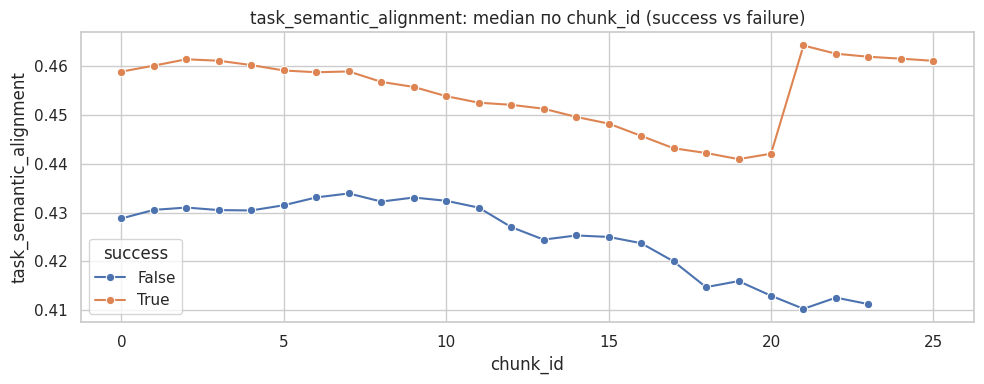

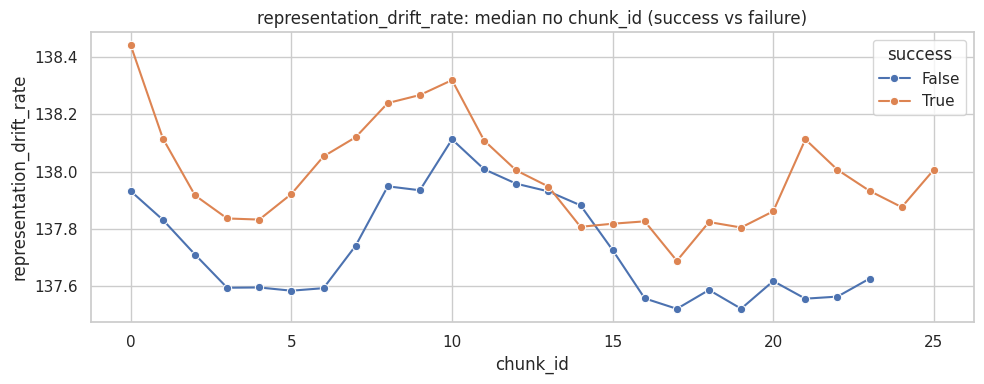

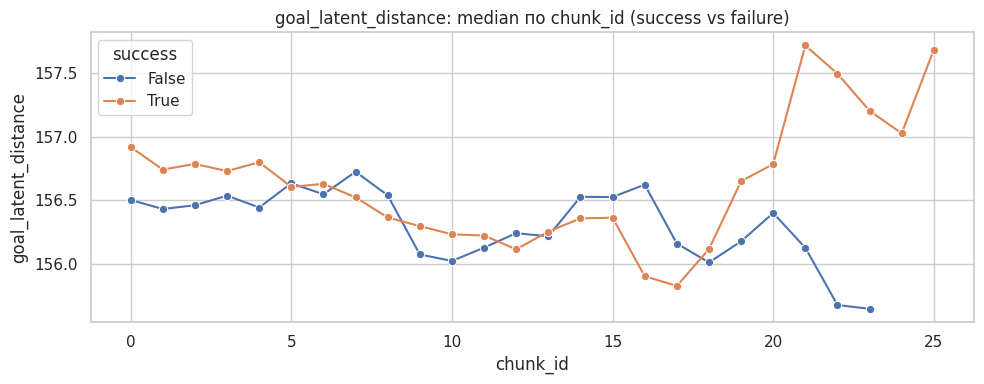

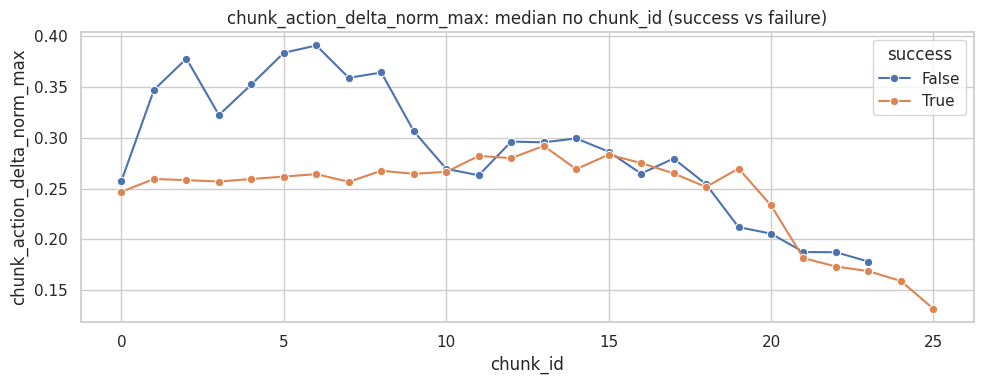

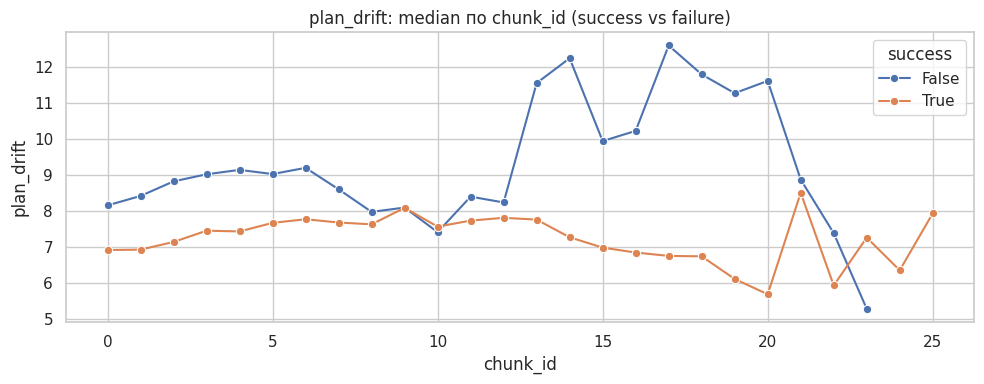

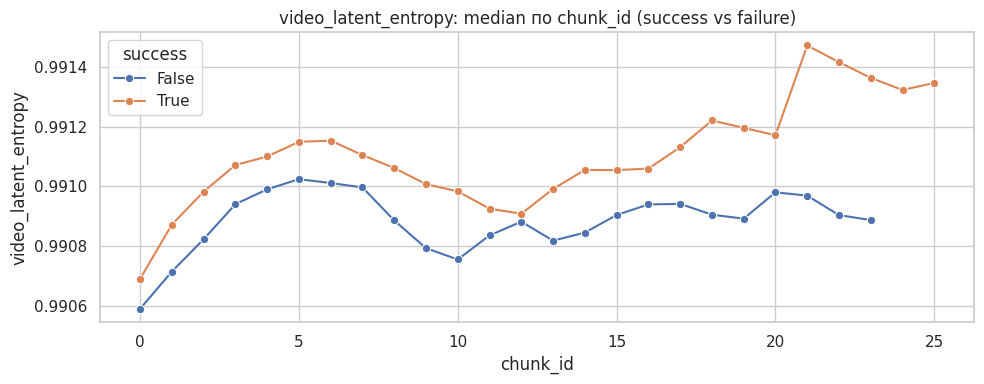

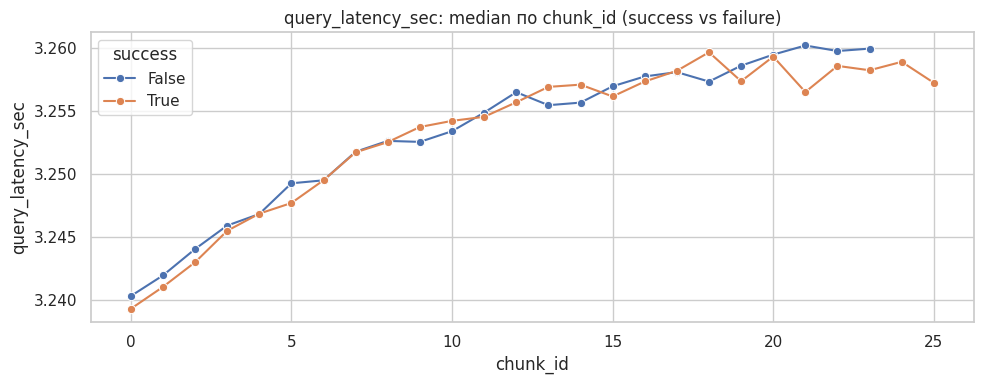

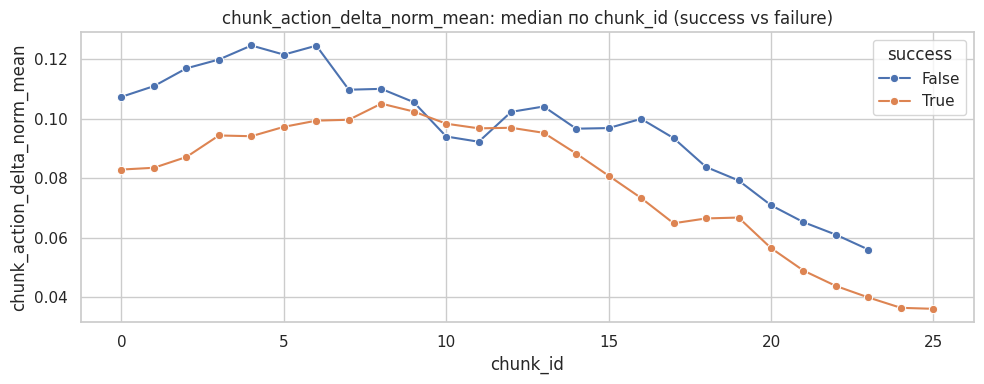

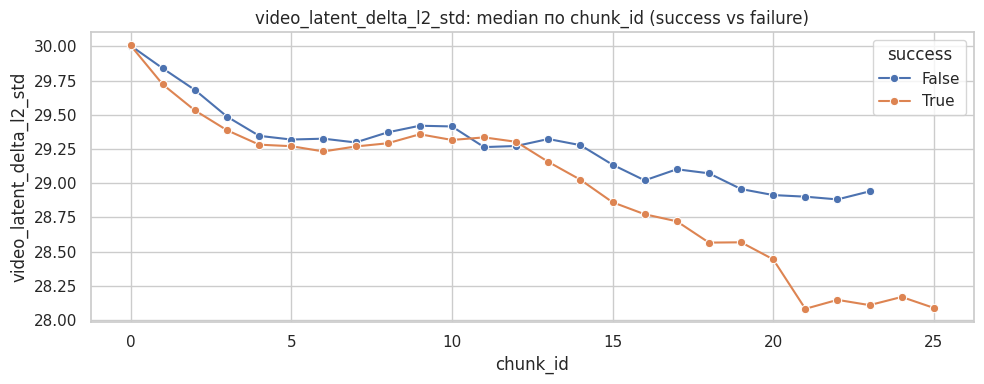

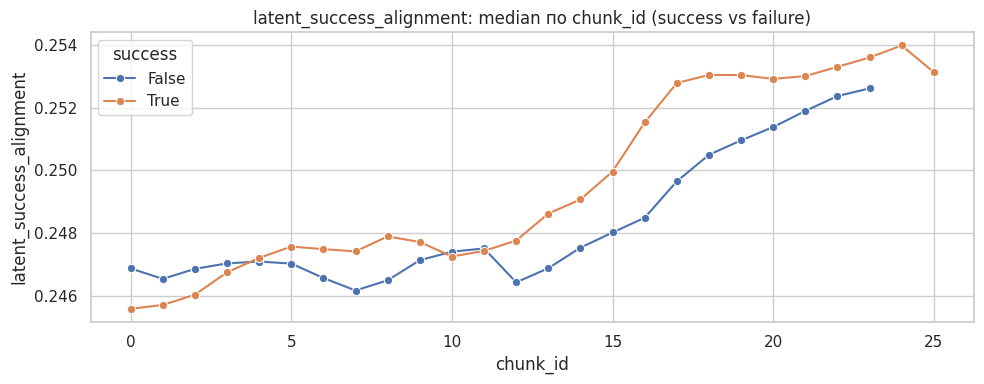

In [4]:
def plot_trend_by_chunk(metric: str, stat: str = "median"):
    g = (
        df[["chunk_id", "success", metric]]
        .dropna()
        .groupby(["chunk_id", "success"])[metric]
    )
    if stat == "mean":
        agg = g.mean().reset_index(name="value")
    elif stat == "median":
        agg = g.median().reset_index(name="value")
    else:
        raise ValueError("stat must be mean or median")

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=agg, x="chunk_id", y="value", hue="success", marker="o")
    plt.title(f"{metric}: {stat} по chunk_id (success vs failure)")
    plt.xlabel("chunk_id")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

for m in top_features:
    plot_trend_by_chunk(m, stat="median")


## 2) Распределения: violin по `chunk_id` (success vs failure)

Violin хорошо показывает форму распределений. Чтобы графики не были «шумными», по умолчанию берем `inner='quartile'` и `cut=0`.

Если графиков слишком много — можно ограничить `MAX_CHUNK_ID` (например 8–12) выше.

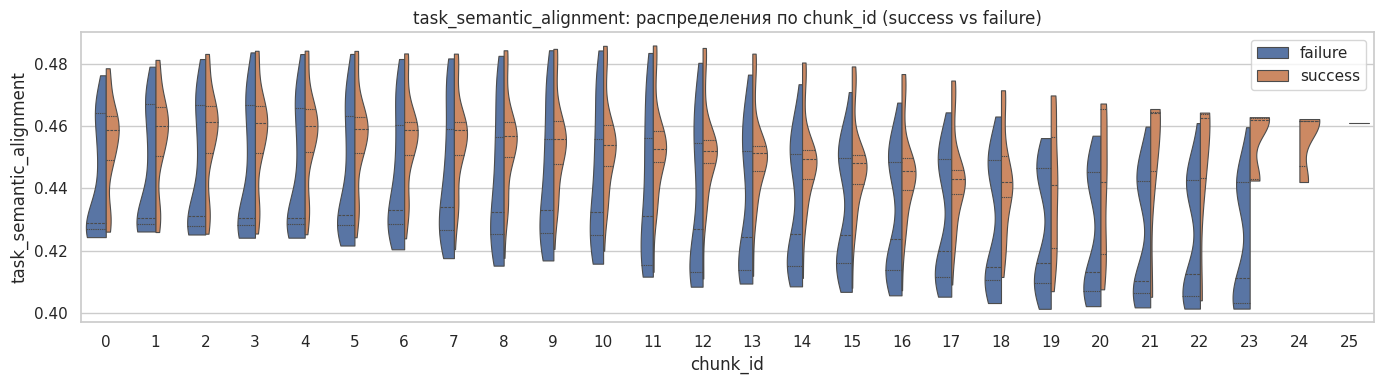

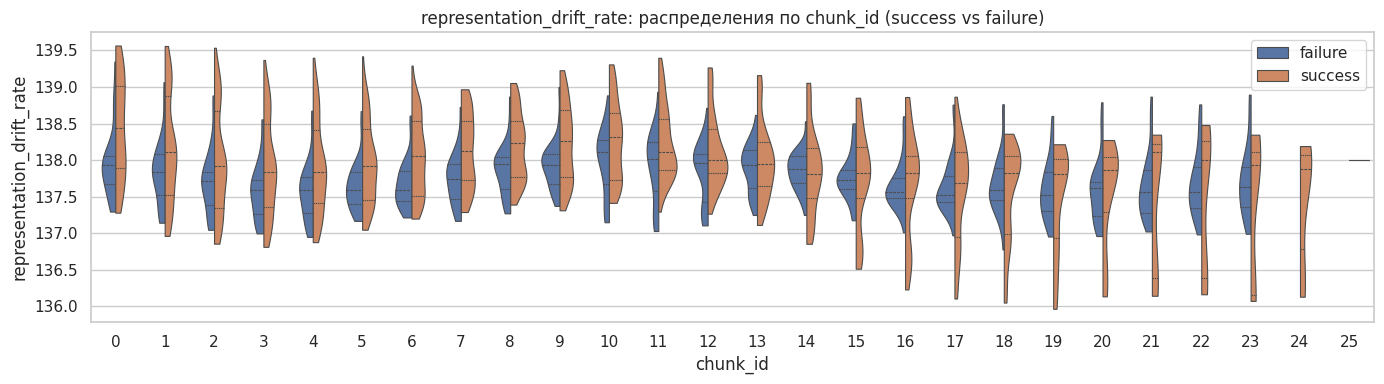

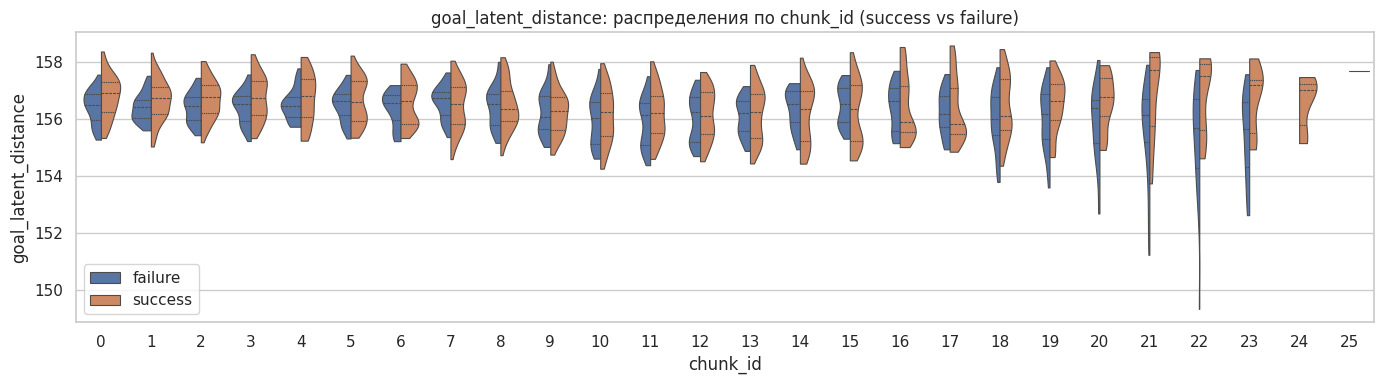

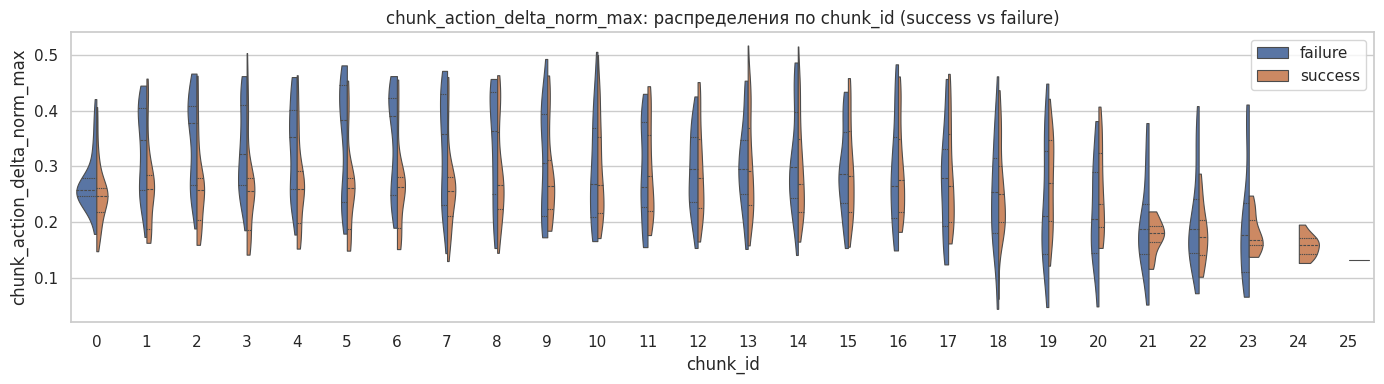

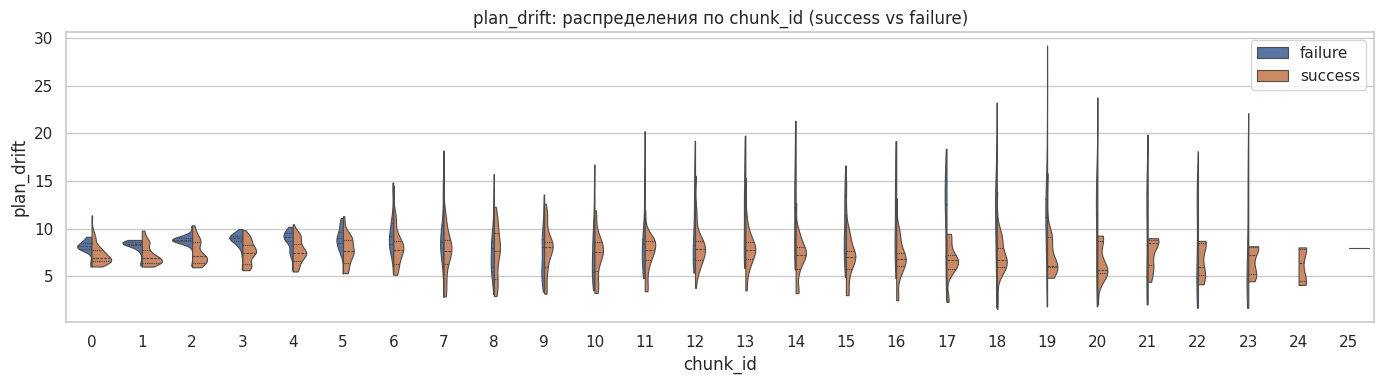

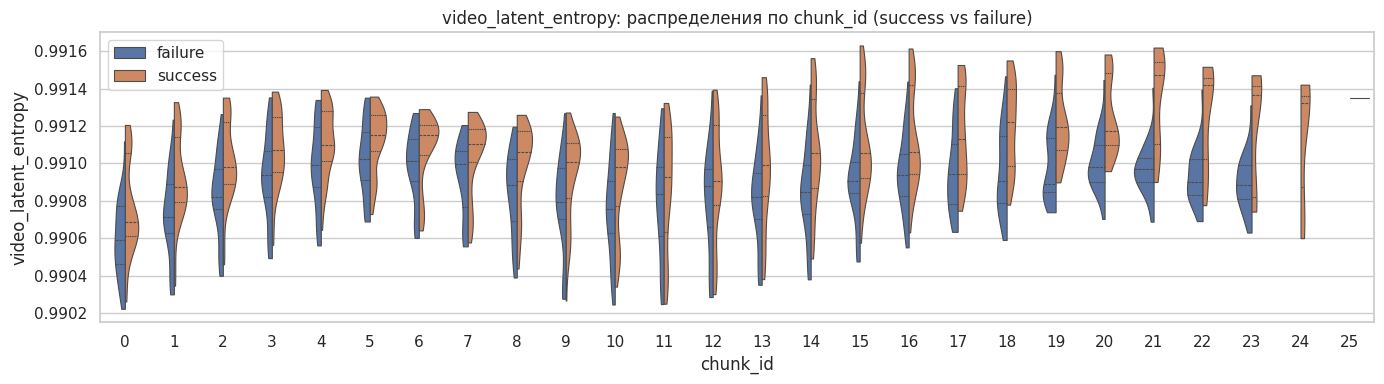

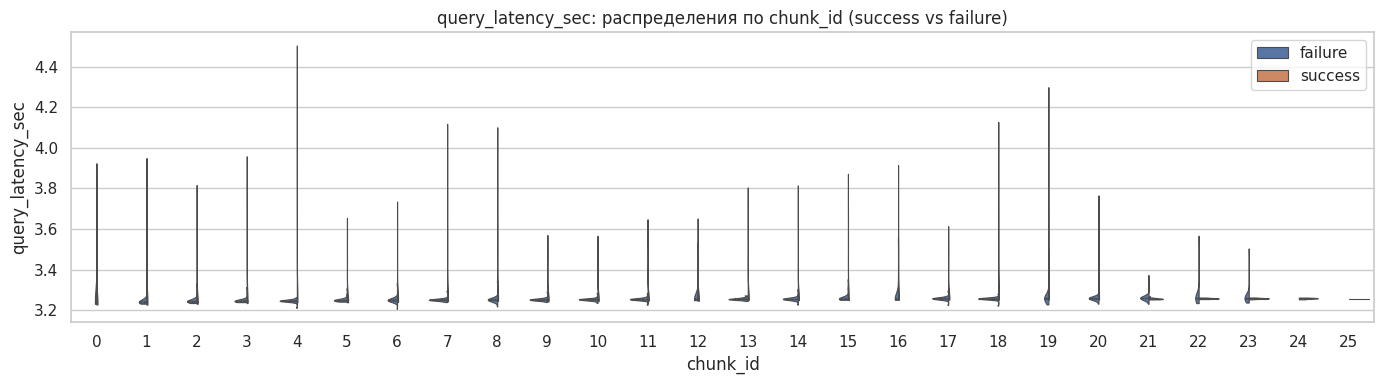

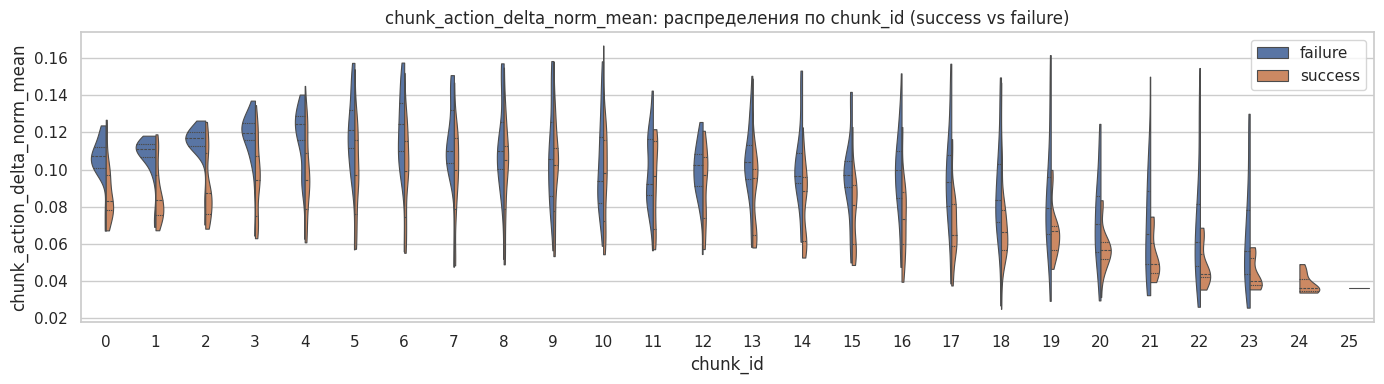

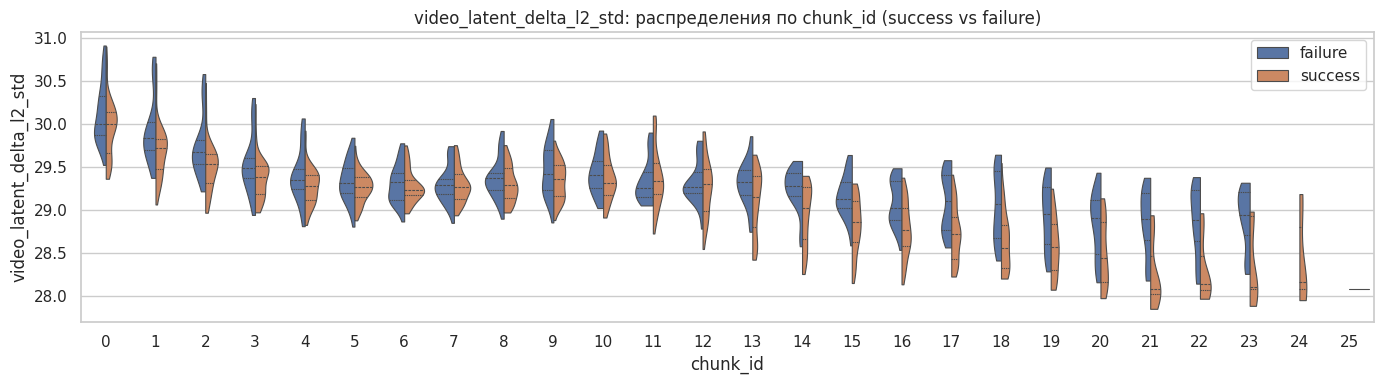

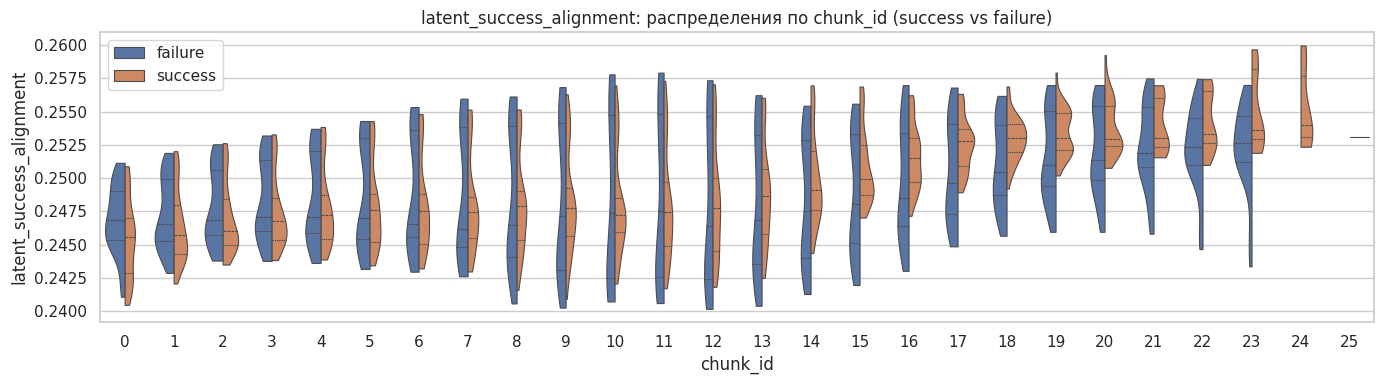

In [5]:
def plot_violin_by_chunk(metric: str):
    data = df[["chunk_id", "success", metric]].dropna().copy()
    data["success"] = data["success"].map({True: "success", False: "failure"})

    plt.figure(figsize=(14, 4))
    sns.violinplot(
        data=data,
        x="chunk_id",
        y=metric,
        hue="success",
        split=True,
        inner="quartile",
        cut=0,
        linewidth=0.8,
    )
    plt.title(f"{metric}: распределения по chunk_id (success vs failure)")
    plt.xlabel("chunk_id")
    plt.ylabel(metric)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()

for m in top_features:
    plot_violin_by_chunk(m)


## 3) Быстрый sanity-check: где разделение сильнее

Посчитаем для каждого `chunk_id` разницу медиан между failure и success (по top-10 метрикам).

,metric,chunk_id,median_success,median_failure,failure_minus_success
78,chunk_action_delta_norm_max,0,0.246792,0.257635,0.010843
79,chunk_action_delta_norm_max,1,0.259383,0.346861,0.087479
80,chunk_action_delta_norm_max,2,0.258237,0.377600,0.119363
81,chunk_action_delta_norm_max,3,0.256886,0.322166,0.065281
82,chunk_action_delta_norm_max,4,0.259341,0.352164,0.092824
83,chunk_action_delta_norm_max,5,0.261730,0.383347,0.121617
84,chunk_action_delta_norm_max,6,0.264112,0.390469,0.126357
85,chunk_action_delta_norm_max,7,0.256595,0.358698,0.102102
86,chunk_action_delta_norm_max,8,0.267444,0.363956,0.096512
87,chunk_action_delta_norm_max,9,0.264463,0.306265,0.041801


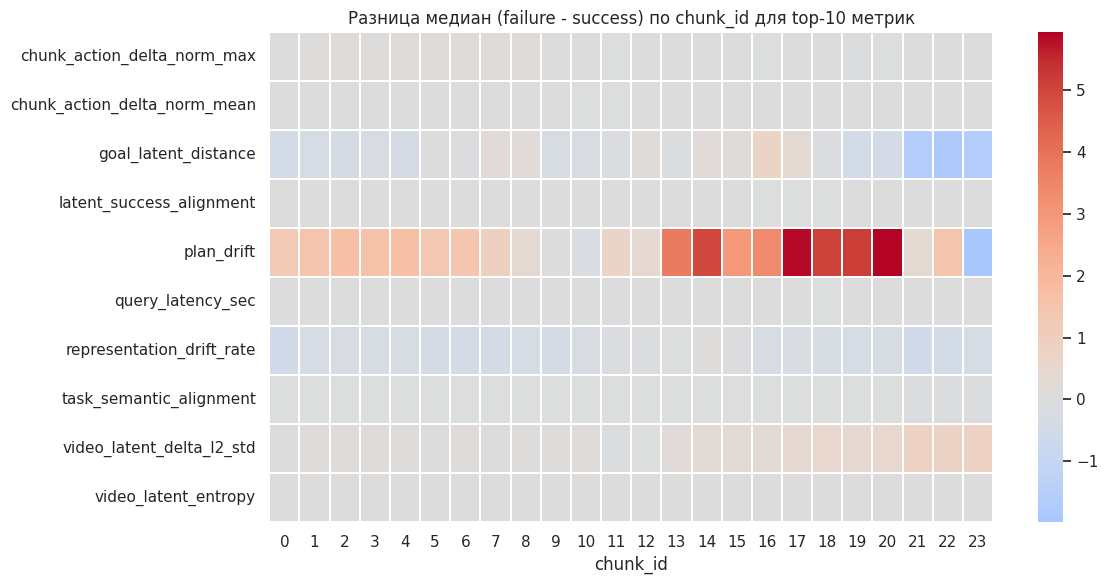

In [6]:
rows = []
for m in top_features:
    g = df[["chunk_id", "success", m]].dropna().groupby(["chunk_id", "success"])[m].median()
    for chunk_id in sorted(df["chunk_id"].unique()):
        s = g.get((chunk_id, True), np.nan)
        f = g.get((chunk_id, False), np.nan)
        rows.append({"metric": m, "chunk_id": int(chunk_id), "median_success": s, "median_failure": f, "failure_minus_success": f - s})

summary = pd.DataFrame(rows)
display(summary.sort_values(["metric", "chunk_id"]).head(30))

plt.figure(figsize=(12, 6))
heat = summary.pivot_table(index="metric", columns="chunk_id", values="failure_minus_success")
sns.heatmap(heat, center=0.0, cmap="coolwarm", linewidths=0.2)
plt.title("Разница медиан (failure - success) по chunk_id для top-10 метрик")
plt.xlabel("chunk_id")
plt.ylabel("")
plt.tight_layout()
plt.show()
